РАЗДЕЛ 1

Сначала импорт библиотек и датасета

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize


df = pd.read_csv("gold.csv")
df.head()

,Date,Open,High,Low,Close,Volume
0,4/13/2009 21:15,892.33,892.55,891.60,892.19,410
1,4/13/2009 21:30,892.28,893.35,891.75,892.20,505
2,4/13/2009 21:45,892.38,893.75,891.10,893.54,679
3,4/13/2009 22:00,893.20,894.03,892.85,893.09,472
4,4/13/2009 22:15,893.07,893.45,892.70,893.42,354


Предварительный анализ данных

In [2]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %H:%M')

In [3]:
print("Предварительный анализ данных:")
print(f"Размер датасета: {df.shape}")
print(f"Типы данных:\n{df.dtypes}")
print(f"Пропущенные значения:\n{df.isnull().sum()}")
print(f"Минимальные значения:\n{df.min()}")
print(f"Максимальные значения:\n{df.max()}")

Предварительный анализ данных:
Размер датасета: (379269, 6)
Типы данных:
Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object
Пропущенные значения:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
Минимальные значения:
Date      2009-04-13 21:15:00
Open                   865.66
High                    865.8
Low                    864.54
Close                  865.67
Volume                      1
dtype: object
Максимальные значения:
Date      2025-08-01 11:45:00
Open                  3497.39
High                  3499.94
Low                   3488.84
Close                  3497.4
Volume                  52676
dtype: object


Построение вариационного ряда по определенному признаку

In [4]:
df_close = df['Close'].values
var_ser = np.sort(df_close)
print(f"Вариационный ряд: {var_ser}")

Вариационный ряд: [ 865.67  865.73  865.8  ... 3490.34 3494.25 3497.4 ]


Определение количества интервалов по формуле Стерджесса

In [5]:
n = len(df_close)
k = int(1 + 3.322 * np.log10(n))
print(f"Количество интервалов по формуле Стерджесса: {k}")

Количество интервалов по формуле Стерджесса: 19


Построение гистограммы относительных частот, полигона относительных частот и эмпирической функции распределения.
Подсчет выборочного среднего, выборочной дисперсии, СКО, коэффициента вариации.

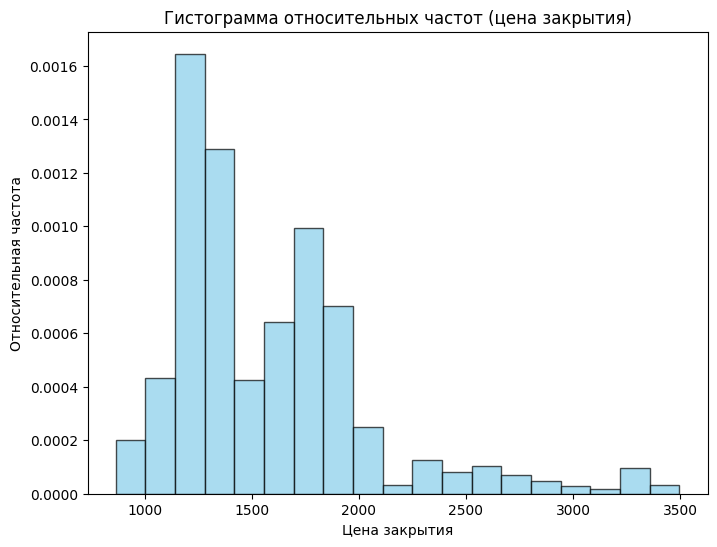

In [6]:
plt.figure(figsize=(8, 6))
counts, bins, patches = plt.hist(df_close, bins=k, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Гистограмма относительных частот (цена закрытия)')
plt.xlabel('Цена закрытия')
plt.ylabel('Относительная частота')
plt.show()

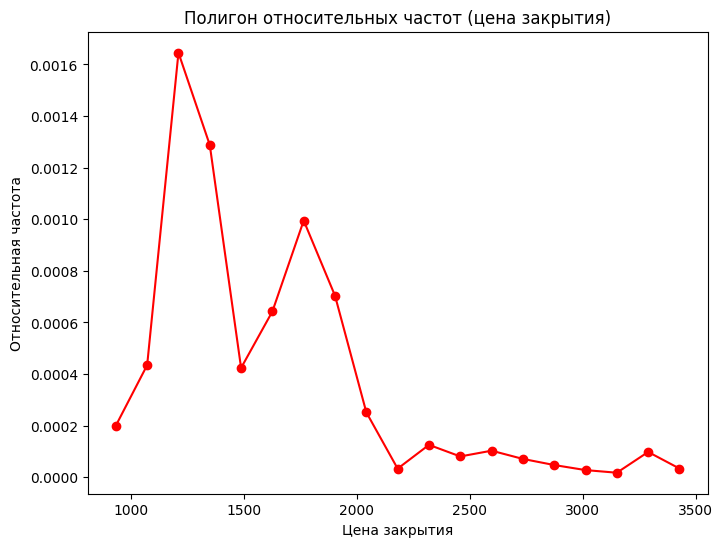

In [7]:
plt.figure(figsize=(8, 6))
midpoints = (bins[:-1] + bins[1:]) / 2
plt.plot(midpoints, counts, marker='o', linestyle='-', color='red')
plt.title('Полигон относительных частот (цена закрытия)')
plt.xlabel('Цена закрытия')
plt.ylabel('Относительная частота')
plt.show()

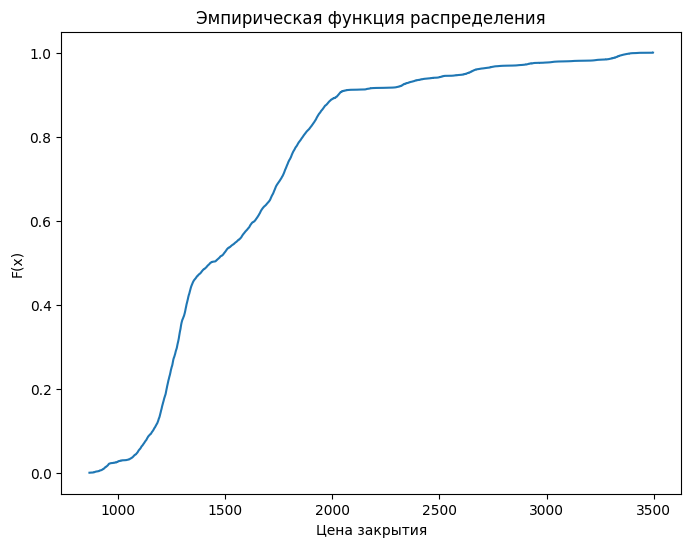

In [8]:
plt.figure(figsize=(8, 6))
x_sorted = np.sort(df_close)
y = np.arange(1, n + 1) / n
plt.step(x_sorted, y, where='post')
plt.title('Эмпирическая функция распределения')
plt.xlabel('Цена закрытия')
plt.ylabel('F(x)')
plt.show()

In [9]:
sample_mean = np.mean(df_close)
sample_var = np.var(df_close, ddof=1)
sample_std = np.std(df_close, ddof=1)
coef_var = sample_std / sample_mean

print(f"Выборочное среднее: {sample_mean:.4f}")
print(f"Выборочная дисперсия: {sample_var:.4f}")
print(f"Выборочное среднеквадратическое отклонение: {sample_std:.4f}")
print(f"Коэффициент вариации: {coef_var:.4f}")

Выборочное среднее: 1580.5012
Выборочная дисперсия: 218490.4665
Выборочное среднеквадратическое отклонение: 467.4296
Коэффициент вариации: 0.2957


In [10]:
def analyze_distribution(df_close, feature_name="Close"):    
    distributions = {
        'Нормальное': stats.norm,
        'Гамма': stats.gamma,
        'Экспоненциальное': stats.expon,
        'Логнормальное': stats.lognorm
    }
    
    best_fit_aic = None
    best_fit_bic = None
    best_aic = np.inf
    best_bic = np.inf
    n = len(df_close)
    
    results = []
    
    print(f"АНАЛИЗ РАСПРЕДЕЛЕНИЯ ДЛЯ ПЕРЕМЕННОЙ: {feature_name}")
    print("=" * 60)
    
    for name, dist in distributions.items():
        try:
            if name == 'Логнормальное':
                params = dist.fit(df_close, floc=0)
            else:
                params = dist.fit(df_close)
            
            k = len(params)  # количество параметров
            log_likelihood = np.sum(dist.logpdf(df_close, *params))
            
            # Критерий Акаике (AIC)
            aic = 2 * k - 2 * log_likelihood
            
            # Критерий Шварца (BIC)
            bic = k * np.log(n) - 2 * log_likelihood
            
            results.append({
                'distribution': name,
                'params': params,
                'aic': aic,
                'bic': bic,
                'log_likelihood': log_likelihood,
                'k_params': k
            })
            
            print(f"{name}:")
            print(f"  AIC = {aic:.2f}, BIC = {bic:.2f}")
            print(f"  Параметры = {params}")
            print(f"  Log-Likelihood = {log_likelihood:.2f}")
            print("-" * 40)
            
            # Обновление лучших моделей
            if aic < best_aic:
                best_aic = aic
                best_fit_aic = name
                
            if bic < best_bic:
                best_bic = bic
                best_fit_bic = name
                
        except Exception as e:
            print(f"{name}: не удалось оценить - {e}")
            print("-" * 40)
    
    # ВЫВОД РЕЗУЛЬТАТОВ
    print("\n" + "=" * 60)
    print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ:")
    print("=" * 60)
    print(f"ЛУЧШАЯ МОДЕЛЬ ПО AIC: {best_fit_aic} (AIC = {best_aic:.2f})")
    print(f"ЛУЧШАЯ МОДЕЛЬ ПО BIC: {best_fit_bic} (BIC = {best_bic:.2f})")
    
    # Сравнение критериев
    if best_fit_aic == best_fit_bic:
        print("✓ Оба критерия выбрали одинаковое распределение")
    else:
        print("⚠ Критерии выбрали разные распределения")
        print("BIC более строгий и склонен выбирать модели с меньшим числом параметров")
    
    # Ранжирование моделей
    print("\nРАНЖИРОВАНИЕ МОДЕЛЕЙ:")
    results_sorted_aic = sorted(results, key=lambda x: x['aic'])
    results_sorted_bic = sorted(results, key=lambda x: x['bic'])
    
    print("\nПо AIC (от лучшей к худшей):")
    for i, res in enumerate(results_sorted_aic, 1):
        print(f"{i}. {res['distribution']}: AIC = {res['aic']:.2f}")
    
    print("\nПо BIC (от лучшей к худшей):")
    for i, res in enumerate(results_sorted_bic, 1):
        print(f"{i}. {res['distribution']}: BIC = {res['bic']:.2f}")
    
    return best_fit_aic, best_fit_bic, results

# Использование функции
best_aic, best_bic, results = analyze_distribution(df_close, "Close")

АНАЛИЗ РАСПРЕДЕЛЕНИЯ ДЛЯ ПЕРЕМЕННОЙ: Close
Нормальное:
  AIC = 5739243.63, BIC = 5739265.32
  Параметры = (np.float64(1580.501186545697), np.float64(467.429021812429))
  Log-Likelihood = -2869619.82
----------------------------------------
Гамма:
  AIC = 5592068.75, BIC = 5592101.29
  Параметры = (np.float64(2.6879812413022632), np.float64(857.3995040698787), np.float64(269.01291970968146))
  Log-Likelihood = -2796031.38
----------------------------------------
Экспоненциальное:
  AIC = 5743688.94, BIC = 5743710.63
  Параметры = (865.67, 714.831186545697)
  Log-Likelihood = -2871842.47
----------------------------------------
Логнормальное:
  AIC = 5623949.79, BIC = 5623982.33
  Параметры = (np.float64(0.26364988986256827), 0, np.float64(1522.9176740137118))
  Log-Likelihood = -2811971.90
----------------------------------------

ИТОГОВЫЕ РЕЗУЛЬТАТЫ:
ЛУЧШАЯ МОДЕЛЬ ПО AIC: Гамма (AIC = 5592068.75)
ЛУЧШАЯ МОДЕЛЬ ПО BIC: Гамма (BIC = 5592101.29)
✓ Оба критерия выбрали одинаковое распредел

Метод максимального правдоподобия

In [11]:
def gamma_mle_estimator(sample):
    fit_alpha, fit_loc, fit_beta = stats.gamma.fit(sample, floc=0)
    return fit_alpha, fit_beta

k_mle, theta_mle = gamma_mle_estimator(df['Close'])
print("\nМетод максимального правдоподобия (MLE):")
print(f"Оценка k (shape): {k_mle:.4f}")
print(f"Оценка θ (scale): {theta_mle:.4f}")

print(f"Оценка μ: {k_mle * theta_mle:.4f}")
print(f"Оценка σ: {(k_mle * theta_mle ** 2) ** 0.5:.4f}")


Метод максимального правдоподобия (MLE):
Оценка k (shape): 13.6366
Оценка θ (scale): 115.9016
Оценка μ: 1580.5012
Оценка σ: 427.9984


Метод моментов для гамма распределения

In [12]:
def gamma_mom_estimator(sample):
    sample_mean = np.mean(sample)
    sample_var = np.var(sample, ddof=0)
    theta_hat_mom = sample_var / sample_mean
    k_hat_mom = sample_mean / theta_hat_mom
    return k_hat_mom, theta_hat_mom

k_mom, theta_mom = gamma_mom_estimator(df_close)
print("Метод моментов:")
print(f"Оценка k (shape): {k_mom:.4f}")
print(f"Оценка θ (scale): {theta_mom:.4f}")

print(f"Оценка μ: {k_mom * theta_mom:.4f}")
print(f"Оценка σ: {(k_mom * theta_mom ** 2) ** 0.5:.4f}")

Метод моментов:
Оценка k (shape): 11.4330
Оценка θ (scale): 138.2409
Оценка μ: 1580.5012
Оценка σ: 467.4290


Байесовский метод

In [13]:
def bayes_estimator(sample, k_known=None):
    if k_known is None:
        k_known, _ = gamma_mle_estimator(sample)
    
    n = len(sample)
    alpha_prior = 0.1
    beta_prior = 0.1

    alpha_post_beta = alpha_prior + n * k_known
    beta_post_beta = beta_prior + np.sum(sample)

    if alpha_post_beta > 1:
        theta = beta_post_beta / (alpha_post_beta - 1)
    else:
        theta = beta_post_beta / (alpha_post_beta + 1)
    
    return theta, k_known

theta, k_known = bayes_estimator(df_close)

print("Байесовская оценка:")
print(f"Оценка k (shape): {k_known:.4f}")
print(f"Оценка θ (scale): {theta:.4f}")

print(f"Оценка μ: {k_known * theta:.4f}")
print(f"Оценка σ: {(k_known * theta ** 2) ** 0.5:.4f}")

Байесовская оценка:
Оценка k (shape): 13.6366
Оценка θ (scale): 115.9016
Оценка μ: 1580.5015
Оценка σ: 427.9985


Проверка свойств на несмещенность, состоятельность, эффективность и асимптотическую нормальность

In [14]:
from scipy.stats import jarque_bera

print("=== ПРОВЕРКА СВОЙСТВ ОЦЕНОК ===")

true_mu = sample_mean
true_sigma2 = sample_var
true_sigma = sample_std

print(f"Истинные параметры:")
print(f"μ = {sample_mean:.4f}")
print(f"σ² = {sample_var:.4f}") 
print(f"σ = {sample_std:.4f}")

n_simulations = 500
sample_sizes = [100, 500, 1000, 5000]

=== ПРОВЕРКА СВОЙСТВ ОЦЕНОК ===
Истинные параметры:
μ = 1580.5012
σ² = 218490.4665
σ = 467.4296


In [15]:
def get_mu_sigma_estimates(sample, method, k_known=None):
    if method == "MLE":
        k_est, theta_est = gamma_mle_estimator(sample)
        mu_est = k_est * theta_est
        sigma_est = np.sqrt(k_est * theta_est**2)
        
    elif method == "MOM":
        k_est, theta_est = gamma_mom_estimator(sample)
        mu_est = k_est * theta_est
        sigma_est = np.sqrt(k_est * theta_est**2)
        
    elif method == "BAYES":
        theta_est, k_est = bayes_estimator(sample, k_known)
        mu_est = k_est * theta_est
        sigma_est = np.sqrt(k_est * theta_est**2)
    
    return mu_est, sigma_est


1. ПРОВЕРКА НЕСМЕЩЕННОСТИ

СМЕЩЕНИЯ ОЦЕНОК (n = 5000):
Метод      Bias(μ)         Bias(σ)        
---------------------------------------------
MLE           -0.239166     0.157668
MOM           -0.239166     0.095146
BAYES         -0.214239     0.165046


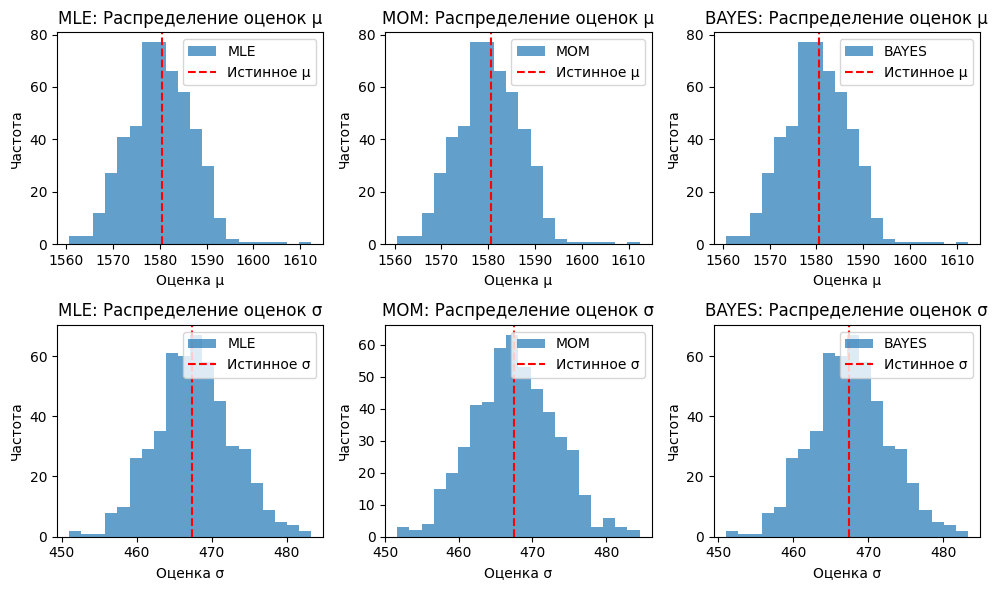

In [16]:
print("\n" + "="*50)
print("1. ПРОВЕРКА НЕСМЕЩЕННОСТИ")
print("="*50)

n_large = 5000
mu_estimates = {"MLE": [], "MOM": [], "BAYES": []}
sigma_estimates = {"MLE": [], "MOM": [], "BAYES": []}

for i in range(n_simulations):
    true_k = true_mu**2 / true_sigma2
    true_theta = true_sigma2 / true_mu
    
    sample = np.random.gamma(true_k, true_theta, n_large)
    
    for method in ["MLE", "MOM", "BAYES"]:
        mu_est, sigma_est = get_mu_sigma_estimates(sample, method)
        mu_estimates[method].append(mu_est)
        sigma_estimates[method].append(sigma_est)

print("\nСМЕЩЕНИЯ ОЦЕНОК (n = 5000):")
print(f"{'Метод':<10} {'Bias(μ)':<15} {'Bias(σ)':<15}")
print("-" * 45)
for method in ["MLE", "MOM", "BAYES"]:
    bias_mu = np.mean(mu_estimates[method]) - true_mu
    bias_sigma = np.mean(sigma_estimates[method]) - true_sigma
    print(f"{method:<10} {bias_mu:>12.6f} {bias_sigma:>12.6f}")

plt.figure(figsize=(10, 6))
for i, method in enumerate(["MLE", "MOM", "BAYES"]):
    plt.subplot(2, 3, i+1)
    plt.hist(mu_estimates[method], bins=20, alpha=0.7, label=f'{method}')
    plt.axvline(true_mu, color='red', linestyle='--', label='Истинное μ')
    plt.xlabel('Оценка μ')
    plt.ylabel('Частота')
    plt.title(f'{method}: Распределение оценок μ')
    plt.legend()

for i, method in enumerate(["MLE", "MOM", "BAYES"]):
    plt.subplot(2, 3, i+4)
    plt.hist(sigma_estimates[method], bins=20, alpha=0.7, label=f'{method}')
    plt.axvline(true_sigma, color='red', linestyle='--', label='Истинное σ')
    plt.xlabel('Оценка σ')
    plt.ylabel('Частота')
    plt.title(f'{method}: Распределение оценок σ')
    plt.legend()

plt.tight_layout()
plt.show()


2. ПРОВЕРКА СОСТОЯТЕЛЬНОСТИ


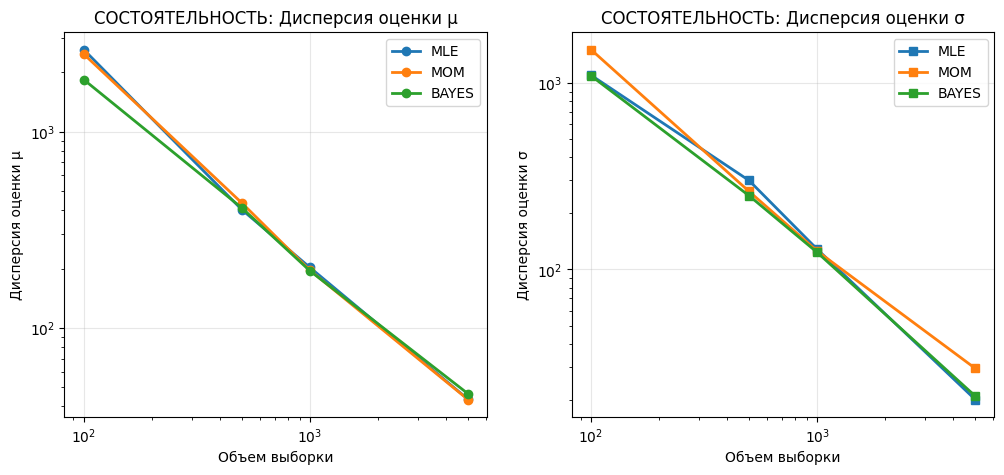


УМЕНЬШЕНИЕ ДИСПЕРСИИ (n=100 → n=5000):
Метод      Уменьшение Var(μ)    Уменьшение Var(σ)   
-------------------------------------------------------
MLE                      60.1x               54.9x
MOM                      57.3x               51.3x
BAYES                    39.7x               52.2x


In [17]:
print("\n" + "="*50)
print("2. ПРОВЕРКА СОСТОЯТЕЛЬНОСТИ")
print("="*50)

variances = {method: {"mu": [], "sigma": []} for method in ["MLE", "MOM", "BAYES"]}

for n in sample_sizes:
    for method in ["MLE", "MOM", "BAYES"]:
        mu_ests = []
        sigma_ests = []
        
        for i in range(100):
            true_k = true_mu**2 / true_sigma2
            true_theta = true_sigma2 / true_mu
            sample = np.random.gamma(true_k, true_theta, n)
            
            mu_est, sigma_est = get_mu_sigma_estimates(sample, method)
            mu_ests.append(mu_est)
            sigma_ests.append(sigma_est)
        
        variances[method]["mu"].append(np.var(mu_ests))
        variances[method]["sigma"].append(np.var(sigma_ests))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for method in ["MLE", "MOM", "BAYES"]:
    plt.plot(sample_sizes, variances[method]["mu"], 'o-', label=method, linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Объем выборки')
plt.ylabel('Дисперсия оценки μ')
plt.title('СОСТОЯТЕЛЬНОСТЬ: Дисперсия оценки μ')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for method in ["MLE", "MOM", "BAYES"]:
    plt.plot(sample_sizes, variances[method]["sigma"], 's-', label=method, linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Объем выборки')
plt.ylabel('Дисперсия оценки σ')
plt.title('СОСТОЯТЕЛЬНОСТЬ: Дисперсия оценки σ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nУМЕНЬШЕНИЕ ДИСПЕРСИИ (n=100 → n=5000):")
print(f"{'Метод':<10} {'Уменьшение Var(μ)':<20} {'Уменьшение Var(σ)':<20}")
print("-" * 55)
for method in ["MLE", "MOM", "BAYES"]:
    reduction_mu = variances[method]["mu"][0] / variances[method]["mu"][-1]
    reduction_sigma = variances[method]["sigma"][0] / variances[method]["sigma"][-1]
    print(f"{method:<10} {reduction_mu:>18.1f}x {reduction_sigma:>18.1f}x")


3. ПРОВЕРКА ЭФФЕКТИВНОСТИ
СРАВНЕНИЕ ЭФФЕКТИВНОСТИ (MSE):
Метод      MSE(μ)               MSE(σ)      
--------------------------------------------------
MLE        47.013797            27.368268
MOM        47.013797            31.224415
BAYES      47.003343            27.373032


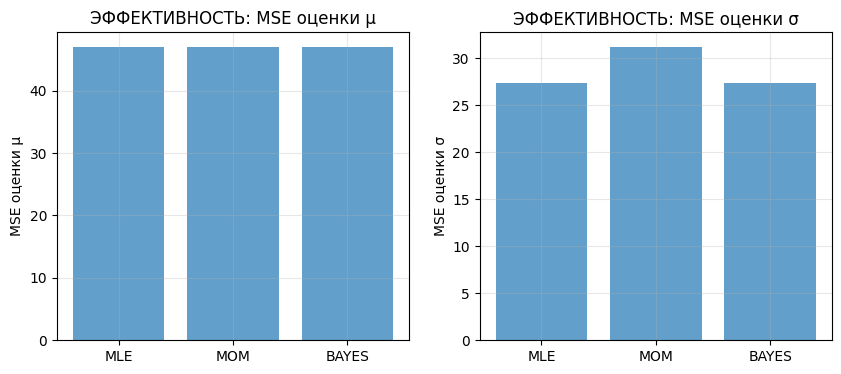

In [18]:
print("\n" + "="*50)
print("3. ПРОВЕРКА ЭФФЕКТИВНОСТИ")
print("="*50)

mse_results = {}
for method in ["MLE", "MOM", "BAYES"]:
    bias_mu = np.mean(mu_estimates[method]) - true_mu
    bias_sigma = np.mean(sigma_estimates[method]) - true_sigma
    
    var_mu = np.var(mu_estimates[method])
    var_sigma = np.var(sigma_estimates[method])
    
    mse_mu = bias_mu**2 + var_mu
    mse_sigma = bias_sigma**2 + var_sigma
    
    mse_results[method] = {
        'bias_mu': bias_mu, 'var_mu': var_mu, 'mse_mu': mse_mu,
        'bias_sigma': bias_sigma, 'var_sigma': var_sigma, 'mse_sigma': mse_sigma
    }

print("СРАВНЕНИЕ ЭФФЕКТИВНОСТИ (MSE):")
print(f"{'Метод':<10} {'MSE(μ)':<20} {'MSE(σ)':<12}")
print("-" * 50)
for method in ["MLE", "MOM", "BAYES"]:
    print(f"{method:<10} {mse_results[method]['mse_mu']:>9.6f} {mse_results[method]['mse_sigma']:>20.6f}")

methods = ["MLE", "MOM", "BAYES"]
mse_mu_values = [mse_results[method]['mse_mu'] for method in methods]
mse_sigma_values = [mse_results[method]['mse_sigma'] for method in methods]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
bars = plt.bar(methods, mse_mu_values, alpha=0.7)
plt.ylabel('MSE оценки μ')
plt.title('ЭФФЕКТИВНОСТЬ: MSE оценки μ')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
bars = plt.bar(methods, mse_sigma_values, alpha=0.7)
plt.ylabel('MSE оценки σ')
plt.title('ЭФФЕКТИВНОСТЬ: MSE оценки σ')
plt.grid(True, alpha=0.3)
plt.show()


4. ПРОВЕРКА АСИМПТОТИЧЕСКОЙ НОРМАЛЬНОСТИ


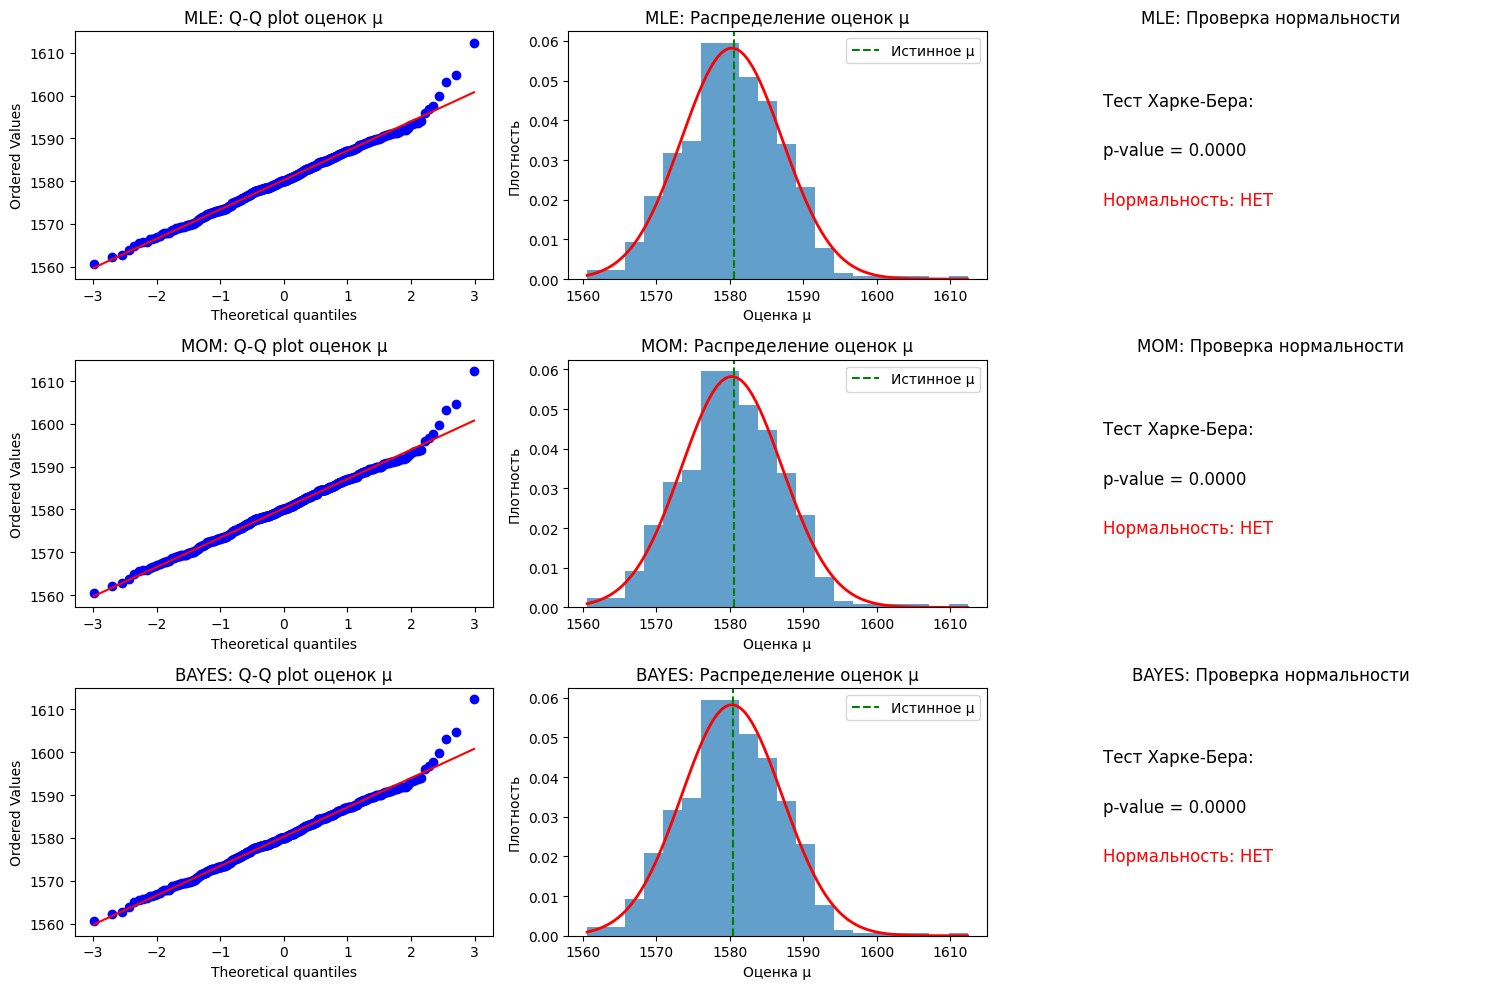


ТЕСТЫ НОРМАЛЬНОСТИ (p-value):
Метод      p-value μ       Нормальность μ 
---------------------------------------------
MLE              0.0000       НЕТ      
MOM              0.0000       НЕТ      
BAYES            0.0000       НЕТ      


In [ ]:
print("\n" + "="*50)
print("4. ПРОВЕРКА АСИМПТОТИЧЕСКОЙ НОРМАЛЬНОСТИ")
print("="*50)

plt.figure(figsize=(15, 10))

for j, method in enumerate(["MLE", "MOM", "BAYES"]):
    plt.subplot(3, 3, j*3 + 1)
    stats.probplot(mu_estimates[method], dist="norm", plot=plt)
    plt.title(f'{method}: Q-Q plot оценок μ')
    
    plt.subplot(3, 3, j*3 + 2)
    n, bins, patches = plt.hist(mu_estimates[method], bins=20, density=True, alpha=0.7)
    
    x = np.linspace(min(mu_estimates[method]), max(mu_estimates[method]), 100)
    y = stats.norm.pdf(x, np.mean(mu_estimates[method]), np.std(mu_estimates[method]))
    plt.plot(x, y, 'r-', linewidth=2)
    plt.axvline(true_mu, color='green', linestyle='--', label='Истинное μ')
    plt.xlabel('Оценка μ')
    plt.ylabel('Плотность')
    plt.title(f'{method}: Распределение оценок μ')
    plt.legend()
    
    plt.subplot(3, 3, j*3 + 3)
    jb_stat, jb_p = jarque_bera(mu_estimates[method])
    
    plt.text(0.1, 0.7, f'Тест Харке-Бера:', fontsize=12)
    plt.text(0.1, 0.5, f'p-value = {jb_p:.4f}', fontsize=12)
    plt.text(0.1, 0.3, f'Нормальность: {"ДА" if jb_p > 0.05 else "НЕТ"}', fontsize=12, color='green' if jb_p > 0.05 else 'red')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.axis('off')
    plt.title(f'{method}: Проверка нормальности')
plt.tight_layout()
plt.show()

print("\nТЕСТЫ НОРМАЛЬНОСТИ (p-value):")
print(f"{'Метод':<10} {'p-value μ':<15} {'Нормальность μ':<15}")
print("-" * 45)
for method in ["MLE", "MOM", "BAYES"]:
    jb_stat, jb_p = jarque_bera(mu_estimates[method])
    is_unial = "ДА" if jb_p > 0.05 else "НЕТ"
    print(f"{method:<10} {jb_p:>12.4f} {is_unial:^15}")

РАЗДЕЛ 2

In [20]:
print("ТОЧЕЧНЫЕ ОЦЕНКИ ХАРАКТЕРИСТИК РАСПРЕДЕЛЕНИЯ")
print("-" * 50)

mean = np.mean(df_close)
median = np.median(df_close)
hist, bin_edges = np.histogram(df_close, bins=k)
mode_bin_index = np.argmax(hist)
mode = (bin_edges[mode_bin_index] + bin_edges[mode_bin_index + 1]) / 2
variance = np.var(df_close, ddof=1)
std = np.std(df_close, ddof=1)

print("Точечные оценки характеристик распределения:")
print(f"Математическое ожидание (выборочное среднее): {mean:.4f}")
print(f"Медиана: {median:.4f}")
print(f"Мода: {mode:.4f}")
print(f"Дисперсия: {variance:.4f}")
print(f"Среднеквадратическое отклонение: {std:.4f}")

ТОЧЕЧНЫЕ ОЦЕНКИ ХАРАКТЕРИСТИК РАСПРЕДЕЛЕНИЯ
--------------------------------------------------
Точечные оценки характеристик распределения:
Математическое ожидание (выборочное среднее): 1580.5012
Медиана: 1431.6300
Мода: 1211.9503
Дисперсия: 218490.4665
Среднеквадратическое отклонение: 467.4296


Доверительные интервалы

In [21]:
def confidence_intervals(data, confidence=0.95):
    n = len(data)
    alpha = 1 - confidence
    
    se_mean = stats.sem(data)
    t_value = stats.t.ppf(1 - alpha/2, n-1)
    ci_mean_lower = mean - t_value * se_mean
    ci_mean_upper = mean + t_value * se_mean

    chi2_lower = stats.chi2.ppf(1 - alpha/2, n-1)
    chi2_upper = stats.chi2.ppf(alpha/2, n-1)
    ci_var_lower = (n-1) * variance / chi2_lower
    ci_var_upper = (n-1) * variance / chi2_upper
    ci_std_lower = np.sqrt(ci_var_lower)
    ci_std_upper = np.sqrt(ci_var_upper)
    
    return {
        'mean': (ci_mean_lower, ci_mean_upper),
        'variance': (ci_var_lower, ci_var_upper),
        'std_dev': (ci_std_lower, ci_std_upper)
    }
    
ci_95 = confidence_intervals(df_close, 0.95)
print("Доверительные интервалы (95%):")
print(f"Среднее: [{ci_95['mean'][0]:.4f}, {ci_95['mean'][1]:.4f}]")
print(f"Дисперсия: [{ci_95['variance'][0]:.4f}, {ci_95['variance'][1]:.4f}]")
print(f"СКО: [{ci_95['std_dev'][0]:.4f}, {ci_95['std_dev'][1]:.4f}]")


Доверительные интервалы (95%):
Среднее: [1579.0136, 1581.9888]
Дисперсия: [217510.4091, 219477.1934]
СКО: [466.3801, 468.4839]


t-критерий Стьюдента

In [22]:
hypothetical_means = [1600, 1580, 1700]

for h_mean in hypothetical_means:
    t_stat, p_value = stats.ttest_1samp(df_close, h_mean)
    
    print(f"\nГипотеза: средняя цена = {h_mean}")
    print(f"t-статистика: {t_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"Гипотеза ОТВЕРГАЕТСЯ (α=0.05)")
        direction = "выше" if mean > h_mean else "ниже"
        print(f"  Средняя цена значимо {direction} {h_mean}")
    else:
        print(f"Гипотеза НЕ ОТВЕРГАЕТСЯ (α=0.05)")
        print(f"  Нет оснований считать среднюю цену отличной от {h_mean}")


Гипотеза: средняя цена = 1600
t-статистика: -25.6901
p-value: 0.0000
Гипотеза ОТВЕРГАЕТСЯ (α=0.05)
  Средняя цена значимо ниже 1600

Гипотеза: средняя цена = 1580
t-статистика: 0.6603
p-value: 0.5090
Гипотеза НЕ ОТВЕРГАЕТСЯ (α=0.05)
  Нет оснований считать среднюю цену отличной от 1580

Гипотеза: средняя цена = 1700
t-статистика: -157.4422
p-value: 0.0000
Гипотеза ОТВЕРГАЕТСЯ (α=0.05)
  Средняя цена значимо ниже 1700


Ядерная оценка плотности

Параметры ядерной оценки плотности:
Используемое ядро: Гауссово
Оптимальная ширина окна: 0.0766
Число точек оценки: 1000

Вероятности нахождения цены в различных диапазонах (KDE):
очень низкие цены [0-1000]: 0.0242 (2.42%)
низкие цены [1000-1500]: 0.4994 (49.94%)
средние цены [1500-2000]: 0.3598 (35.98%)
высокие цены [2000-2500]: 0.0543 (5.43%)
очень высокие цены [2500-inf]: 0.0577 (5.77%)


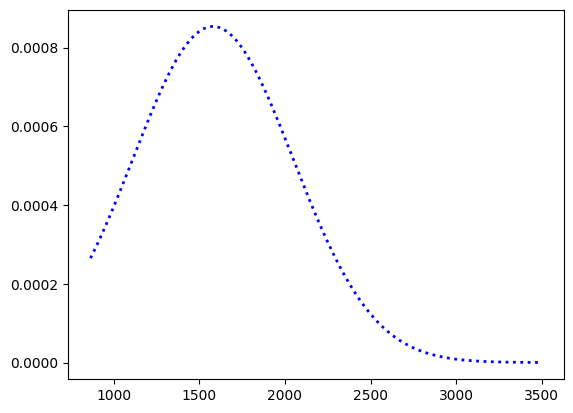

In [ ]:
kde = stats.gaussian_kde(df_close)

x_range = np.linspace(np.min(df_close), np.max(df_close), 1000)
pdf_kde = kde(x_range)

params_gamma = stats.gamma.fit(df_close)
pdf_gamma = stats.gamma.pdf(x_range, *params_gamma)

pdf_uni = stats.norm.pdf(x_range, mean, std)
plt.plot(x_range, pdf_uni, 'b:', linewidth=2, label='Нормальное распределение')

print("Параметры ядерной оценки плотности:")
print(f"Используемое ядро: Гауссово")
print(f"Оптимальная ширина окна: {kde.factor:.4f}")
print(f"Число точек оценки: {len(x_range)}")

price_ranges = [
    (0, 1000, "очень низкие цены"),
    (1000, 1500, "низкие цены"), 
    (1500, 2000, "средние цены"),
    (2000, 2500, "высокие цены"),
    (2500, np.inf, "очень высокие цены")
]

print(f"\nВероятности нахождения цены в различных диапазонах (KDE):")
for low, high, desc in price_ranges:
    mask = (x_range >= low) & (x_range <= high)
    if np.any(mask):
        prob = np.trapezoid(pdf_kde[mask], x_range[mask])
        print(f"{desc} [{low}-{high}]: {prob:.4f} ({prob*100:.2f}%)")

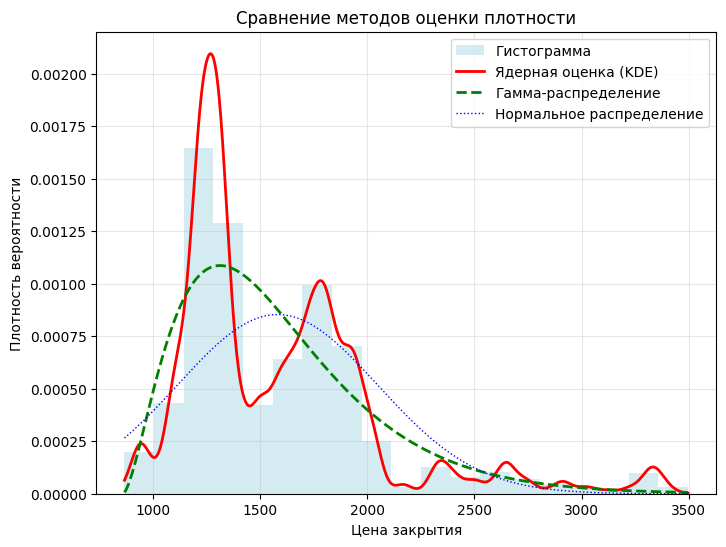

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df_close, bins=k, density=True, alpha=0.5, color='lightblue', label='Гистограмма')
plt.plot(x_range, pdf_kde, 'r-', linewidth=2, label='Ядерная оценка (KDE)')
plt.plot(x_range, pdf_gamma, 'g--', linewidth=2, label='Гамма-распределение')
plt.plot(x_range, pdf_uni, 'b:', linewidth=1, label='Нормальное распределение')
plt.xlabel('Цена закрытия')
plt.ylabel('Плотность вероятности')
plt.title('Сравнение методов оценки плотности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Оценка распределений и плотностей

СРАВНЕНИЕ МЕТОДОВ ОЦЕНКИ ПЛОТНОСТИ
----------------------------------------
Сравнение методов оценки плотности:


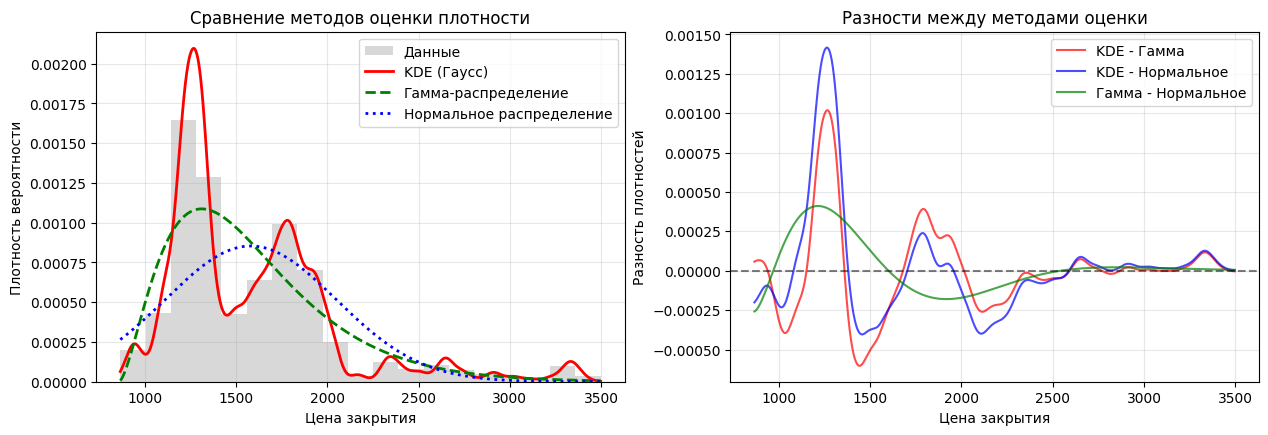

In [ ]:
print("СРАВНЕНИЕ МЕТОДОВ ОЦЕНКИ ПЛОТНОСТИ")
print("-" * 40)
params_gamma = stats.gamma.fit(df_close)
x_range = np.linspace(np.min(df_close), np.max(df_close), 1000)

methods = {
    'Гистограмма (Стерджесс)': {
        'type': 'histogram',
        'bins': k
    },
    'Ядерная оценка (Гаусс)': {
        'type': 'kde', 
        'kernel': 'gaussian'
    },
    'Гамма-распределение': {
        'type': 'parametric',
        'dist': stats.gamma,
        'params': params_gamma
    },
    'Нормальное распределение': {
        'type': 'parametric', 
        'dist': stats.norm,
        'params': (mean, std)
    }
}

print("Сравнение методов оценки плотности:")
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
hist, bins, _ = plt.hist(df_close, bins=k, density=True, alpha=0.3, color='gray', label='Данные')

kde = stats.gaussian_kde(df_close)
pdf_kde = kde(x_range)
plt.plot(x_range, pdf_kde, 'r-', linewidth=2, label='KDE (Гаусс)')

pdf_gamma = stats.gamma.pdf(x_range, *params_gamma)
plt.plot(x_range, pdf_gamma, 'g--', linewidth=2, label='Гамма-распределение')
pdf_uni = stats.norm.pdf(x_range, mean, std)
plt.plot(x_range, pdf_uni, 'b:', linewidth=2, label='Нормальное распределение')

plt.xlabel('Цена закрытия')
plt.ylabel('Плотность вероятности')
plt.title('Сравнение методов оценки плотности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(2, 2, 2)
plt.plot(x_range, pdf_kde - pdf_gamma, 'r-', label='KDE - Гамма', alpha=0.7)
plt.plot(x_range, pdf_kde - pdf_uni, 'b-', label='KDE - Нормальное', alpha=0.7)
plt.plot(x_range, pdf_gamma - pdf_uni, 'g-', label='Гамма - Нормальное', alpha=0.7)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Цена закрытия')
plt.ylabel('Разность плотностей')
plt.title('Разности между методами оценки')
plt.legend()
plt.grid(True, alpha=0.3)

Формирование и проверка гипотез

In [26]:
print("ГИПОТЕЗА 1: Средняя цена золота равна 1600")
print("Обоснование: Проверка значимости отклонения от психологически важного уровня")
t_stat1, p_value1 = stats.ttest_1samp(df_close, 1600)
print(f"t-статистика: {t_stat1:.4f}, p-value: {p_value1:.6f}")
print(f"Результат: {'ОТВЕРГАЕТСЯ' if p_value1 < 0.05 else 'НЕ ОТВЕРГАЕТСЯ'} при α=0.05")

print("\nГИПОТЕЗА 2: Распределение цен симметрично")
print("Обоснование: Асимметрия влияет на риск-профиль актива")
skewness = stats.skew(df_close)
se_skew = np.sqrt(6 * len(df_close) * (len(df_close) - 1) / 
                 ((len(df_close) - 2) * (len(df_close) + 1) * (len(df_close) + 3)))
z_skew = skewness / se_skew
p_skew = 2 * (1 - stats.norm.cdf(abs(z_skew)))
print(f"Коэффициент асимметрии: {skewness:.4f} (нормальное: 0)")
print(f"Z-статистика: {z_skew:.4f}, p-value: {p_skew:.6f}")
print(f"Результат: {'ОТВЕРГАЕТСЯ' if p_skew < 0.05 else 'НЕ ОТВЕРГАЕТСЯ'} при α=0.05")
if p_skew < 0.05:
    direction = "положительную" if skewness > 0 else "отрицательную"
    print(f"  Распределение имеет {direction} асимметрию")

print("\nГИПОТЕЗА 3: Дисперсия цен меньше 220000")
print("Обоснование: Проверка уровня волатильности")
chi2_stat = (len(df_close) - 1) * variance / 220000
chi2_pvalue = 1 - stats.chi2.cdf(chi2_stat, len(df_close)-1)
print(f"χ²-статистика: {chi2_stat:.4f}, p-value: {chi2_pvalue:.6f}")
print(f"Результат: {'ОТВЕРГАЕТСЯ' if chi2_pvalue < 0.05 else 'НЕ ОТВЕРГАЕТСЯ'} при α=0.05")

ГИПОТЕЗА 1: Средняя цена золота равна 1600
Обоснование: Проверка значимости отклонения от психологически важного уровня
t-статистика: -25.6901, p-value: 0.000000
Результат: ОТВЕРГАЕТСЯ при α=0.05

ГИПОТЕЗА 2: Распределение цен симметрично
Обоснование: Асимметрия влияет на риск-профиль актива
Коэффициент асимметрии: 1.5670 (нормальное: 0)
Z-статистика: 393.9680, p-value: 0.000000
Результат: ОТВЕРГАЕТСЯ при α=0.05
  Распределение имеет положительную асимметрию

ГИПОТЕЗА 3: Дисперсия цен меньше 220000
Обоснование: Проверка уровня волатильности
χ²-статистика: 376665.6466, p-value: 0.998624
Результат: НЕ ОТВЕРГАЕТСЯ при α=0.05


РАЗДЕЛ 3

In [35]:
from scipy.stats import chi2

def pearson_test(data, dist_name, bins=k):
    n = len(data)
    hist, bin_edges = np.histogram(data, bins=bins, density=False)
    if dist_name == 'gamma':
        alpha, loc, beta = stats.gamma.fit(data)
        cdf_value = stats.gamma.cdf(bin_edges, alpha, loc, beta)
        df_adjust = 3
    elif dist_name == 'uniform':
        a = np.min(data)
        b = np.max(data)
        cdf_value = stats.uniform.cdf(bin_edges, loc=a, scale=b-a)
        df_adjust = 2
    if cdf_value is None:
        raise ValueError(f"Неизвестное распределение: {dist_name}")
    expected = n * np.diff(cdf_value)
    mask = expected >= 5
    observed_clean = hist[mask]
    expected_clean = expected[mask]
    chi2_stat = np.sum((observed_clean - expected_clean) ** 2 / expected_clean)
    df = len(observed_clean) - 1 - df_adjust
    p_value = 1 - chi2.cdf(chi2_stat, df)
    return chi2_stat, p_value, df, observed_clean, expected_clean

In [36]:
print("Гамма-распределение:")
chi2_gamma, p_gamma, df_gamma, obs_gamma, exp_gamma = pearson_test(df_close, 'gamma')
print(f"χ² статистика: {chi2_gamma:.4f}")
print(f"p-value: {p_gamma:.6f}")
print(f"Результат: {'ОТВЕРГАЕТСЯ' if p_gamma < 0.05 else 'НЕ ОТВЕРГАЕТСЯ'}")
print("\Равномерное распределение")
chi2_uniform, p_uniform, df_unifrom, obs_uniform, exp_uniform = pearson_test(df_close, 'uniform')
print(f"χ² статистика: {chi2_uniform:.4f}")
print(f"p-value: {p_uniform:.6f}")
print(f"Результат: {'ОТВЕРГАЕТСЯ' if p_uniform < 0.05 else 'НЕ ОТВЕРГАЕТСЯ'}")

Гамма-распределение:
χ² статистика: 113297.2582
p-value: 0.000000
Результат: ОТВЕРГАЕТСЯ
\Равномерное распределение
χ² статистика: 559252.3210
p-value: 0.000000
Результат: ОТВЕРГАЕТСЯ


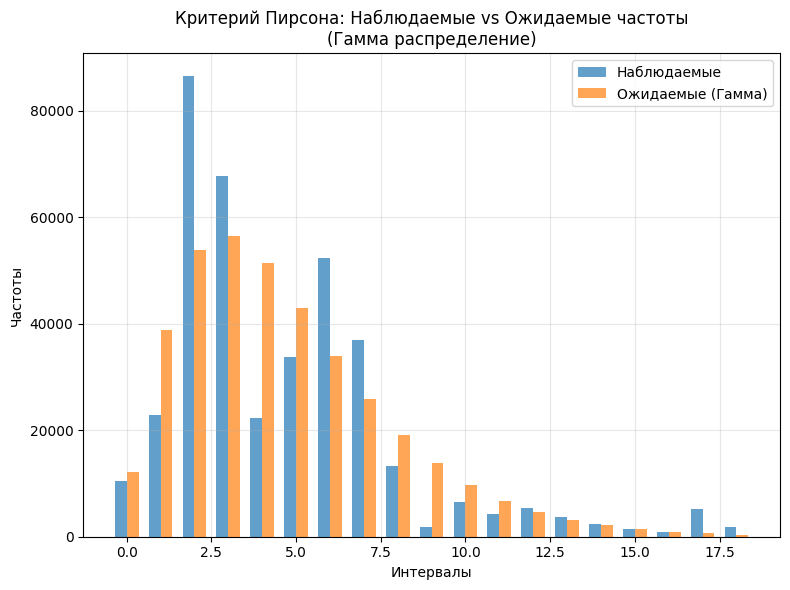

In [37]:
plt.figure(figsize=(8, 6))
x_pos = np.arange(len(obs_gamma))
width = 0.35
plt.bar(x_pos - width/2, obs_gamma, width, label='Наблюдаемые', alpha=0.7)
plt.bar(x_pos + width/2, exp_gamma, width, label='Ожидаемые (Γамма)', alpha=0.7)
plt.xlabel('Интервалы')
plt.ylabel('Частоты')
plt.title('Критерий Пирсона: Наблюдаемые vs Ожидаемые частоты\n(Гамма распределение)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
def anamorphosis(data, dist_name, params=None):
    sorted_data = np.sort(data)
    n = len(data)
    emp_probs = np.arange(1, n + 1) / (n + 1)
    if dist_name == 'gamma':
        if params is None:
            alpha, loc, beta = stats.gamma.fit(data)
        else:
            alpha, loc, beta = params
        theor_q = stats.gamma.ppf(emp_probs, alpha, loc, beta)
    elif dist_name == 'uniform':
        if params is None:
            a = np.min(data)
            b = np.max(data)
        else:
            a, b = params
        theor_q = stats.uniform.ppf(emp_probs, loc=a, scale=b-a)
    slope, intercept = np.polyfit(theor_q, sorted_data, 1)
    reg_line = slope * theor_q + intercept
    ss_res = np.sum((sorted_data - reg_line) ** 2)
    ss_tot = np.sum((sorted_data - np.mean(sorted_data)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    return theor_q, sorted_data, slope, intercept, r_squared

In [41]:
print("Анаморфоза гамма распределения:")
theor_gamma, empir_gamma, slope_gamma, intercept_gamma, r2_gamma = anamorphosis(df_close, 'gamma', params_gamma)
print(f"Угловой коэффициент: {slope_gamma:.4f}")
print(f"Свободный член: {intercept_gamma:.4f}")
print(f"R²: {r2_gamma:.6f}")
print("\nАнаморфоза равномерного распределения:")
theor_uni, empir_uni, slope_uni, intercept_uni, r2_uni = anamorphosis(df_close, 'uniform')
print(f"Угловой коэффициент: {slope_uni:.4f}")
print(f"Свободный член: {intercept_uni:.4f}")
print(f"R²: {r2_uni:.6f}")

Анаморфоза гамма распределения:
Угловой коэффициент: 1.0425
Свободный член: -67.1834
R²: 0.967482

Анаморфоза равномерного распределения:
Угловой коэффициент: 0.5487
Свободный член: 383.3842
R²: 0.795457


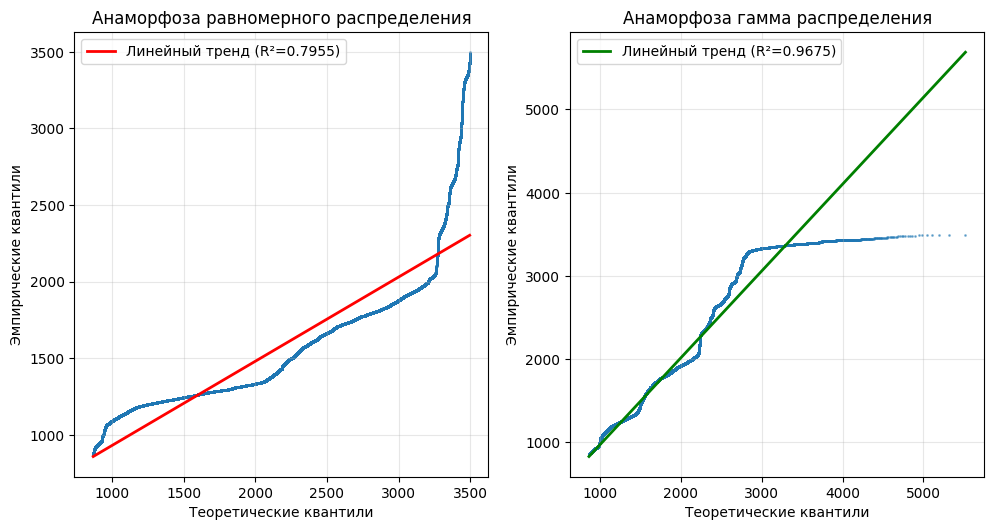

In [43]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.scatter(theor_uni, empir_uni, alpha=0.5, s=1)
regression_line_uni = slope_uni * theor_uni + intercept_uni
plt.plot(theor_uni, regression_line_uni, 'r-', linewidth=2, label=f'Линейный тренд (R²={r2_uni:.4f})')
plt.xlabel('Теоретические квантили')
plt.ylabel('Эмпирические квантили')
plt.title('Анаморфоза равномерного распределения')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 3, 2)
plt.scatter(theor_gamma, empir_gamma, alpha=0.5, s=1)
regression_line_gamma = slope_gamma * theor_gamma + intercept_gamma
plt.plot(theor_gamma, regression_line_gamma, 'g-', linewidth=2, label=f'Линейный тренд (R²={r2_gamma:.4f})')
plt.xlabel('Теоретические квантили')
plt.ylabel('Эмпирические квантили')
plt.title('Анаморфоза гамма распределения')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()